# EDA — GR day-ahead electricity prices

Greek bidding zone (`10YGR-HTSO-----Y`), June 2023 – June 2026, hourly.
Data: ENTSO-E Transparency Platform, built by `scripts/download_data.py`
(see the data-quality report for gaps and resolution changes).

This notebook is exploration only — no modeling logic lives here. We look at:

1. price level and distribution over time,
2. seasonality (hour of day, weekday, month) and the solar **duck curve**,
3. negative-price episodes,
4. price vs **residual load** (load minus solar and wind) — the merit-order view.

Timestamps are converted to **Europe/Athens** local time: market behaviour
(solar noon, evening peak, human activity) follows the local clock.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from gr_epf import data, quality

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

df = data.load_processed().tz_convert("Europe/Athens")
df["hour"] = df.index.hour
df["weekday"] = df.index.weekday
df["month"] = df.index.month
df["year"] = df.index.year
df[["price_eur_mwh", "load_actual_mw", "gen_solar_mw", "gen_wind_onshore_mw"]].describe().round(1)

,price_eur_mwh,load_actual_mw,gen_solar_mw,gen_wind_onshore_mw
count,26568.0,26567.0,26564.0,26564.0
mean,101.3,5682.1,1268.2,1233.2
std,57.4,1264.0,1735.4,848.0
min,-50.0,3074.0,0.0,0.0
25%,77.2,4728.0,0.0,522.0
50%,99.7,5558.0,52.0,1045.0
75%,123.9,6410.0,2509.2,1815.8
max,942.0,11034.0,7874.5,4000.0


**Residual load** = actual load − solar − wind onshore. This is the demand
that *dispatchable* plants (gas, hydro reservoir) must cover, which is what
sets the marginal price. Hydro is left out of the subtraction: our
`gen_hydro_mw` aggregates reservoir (dispatchable, price-setting) with
run-of-river (non-dispatchable but small in the Greek mix), so subtracting
it would mix cause and effect.

In [2]:
df["residual_load_mw"] = df["load_actual_mw"] - df["gen_solar_mw"] - df["gen_wind_onshore_mw"]

## 1. Price overview

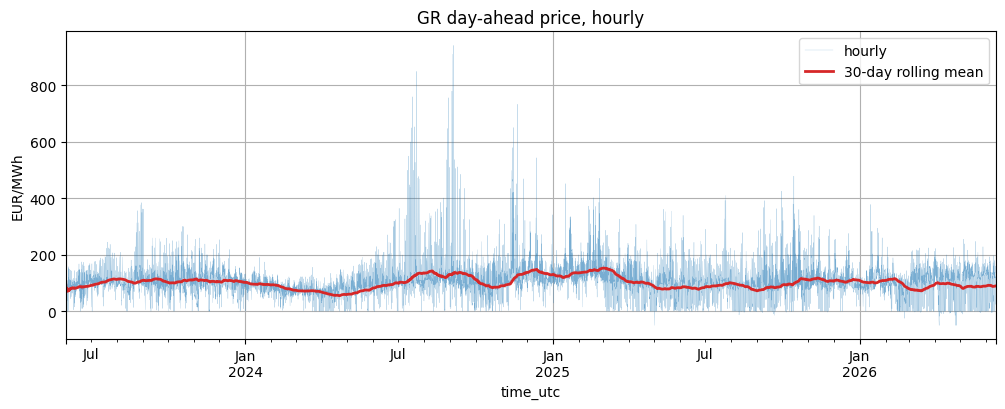

In [3]:
fig, ax = plt.subplots()
df["price_eur_mwh"].plot(ax=ax, lw=0.15, alpha=0.6, color="tab:blue", label="hourly")
rolling = df["price_eur_mwh"].rolling("30D").mean()
rolling.plot(ax=ax, lw=2, color="tab:red", label="30-day rolling mean")
ax.set_ylabel("EUR/MWh")
ax.set_title("GR day-ahead price, hourly")
ax.legend()
plt.show()

In [4]:
stats = df.groupby("year")["price_eur_mwh"].agg(["mean", "std", "min", "max"])
neg_share = df.groupby("year")["price_eur_mwh"].apply(lambda s: 100 * (s < 0).mean())
stats["pct_negative_hours"] = neg_share
stats.round(2)

,mean,std,min,max,pct_negative_hours
year,,,,,
2023,104.97,40.69,0.00,384.82,0.00
2024,100.88,65.71,-1.02,942.00,0.13
2025,103.60,57.16,-50.00,478.91,1.31
2026,92.38,55.99,-50.00,378.48,6.61


Note: 2023 covers June–December and 2026 January–June only, so yearly rows
are not directly comparable levels — but the trend in `pct_negative_hours`
is unmistakable.

## 2. Seasonality and the duck curve

Average price by hour of day, separately per year. If midday solar is
eating the price, the curve should sag around 12:00–15:00 and the sag
should deepen year over year.

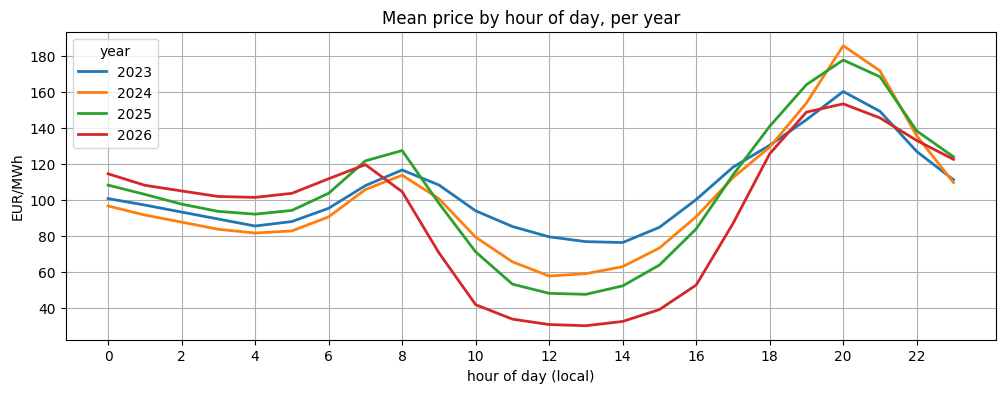

In [5]:
hourly_year = df.groupby(["hour", "year"])["price_eur_mwh"].mean().unstack()
ax = hourly_year.plot(lw=2, title="Mean price by hour of day, per year")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("hour of day (local)")
ax.set_xticks(range(0, 24, 2))
plt.show()

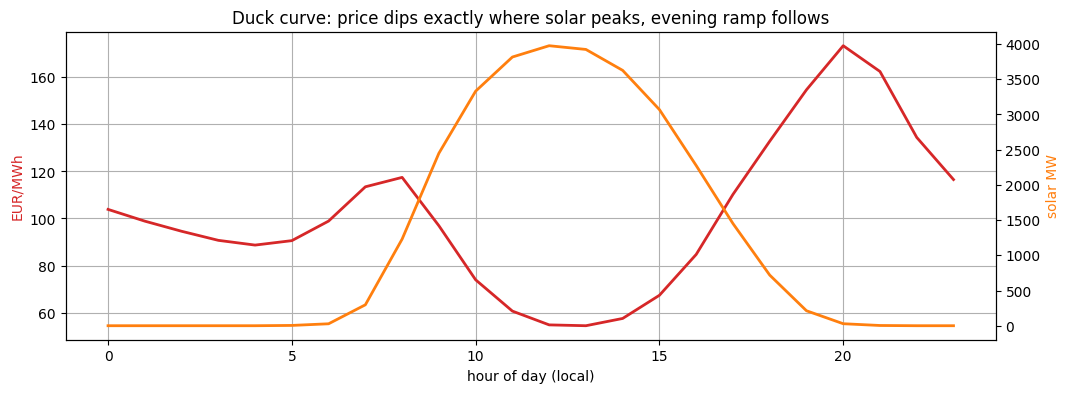

In [6]:
fig, ax1 = plt.subplots()
df.groupby("hour")["price_eur_mwh"].mean().plot(ax=ax1, lw=2, color="tab:red", label="mean price")
ax1.set_ylabel("EUR/MWh", color="tab:red")
ax1.set_xlabel("hour of day (local)")
ax2 = ax1.twinx()
df.groupby("hour")["gen_solar_mw"].mean().plot(ax=ax2, lw=2, color="tab:orange", label="mean solar")
ax2.set_ylabel("solar MW", color="tab:orange")
ax2.grid(False)
ax1.set_title("Duck curve: price dips exactly where solar peaks, evening ramp follows")
plt.show()

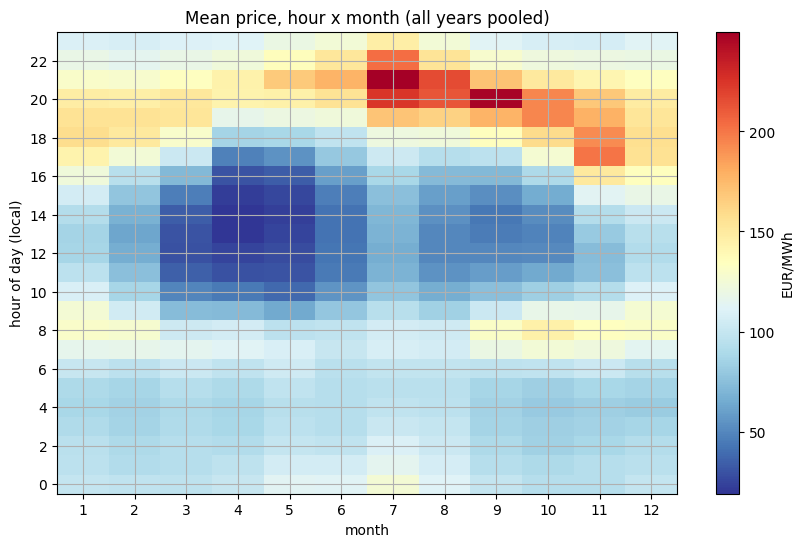

In [7]:
pivot = df.pivot_table(values="price_eur_mwh", index="hour", columns="month", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="RdYlBu_r")
ax.set_xticks(range(12), pivot.columns)
ax.set_yticks(range(0, 24, 2), pivot.index[::2])
ax.set_xlabel("month")
ax.set_ylabel("hour of day (local)")
ax.set_title("Mean price, hour x month (all years pooled)")
fig.colorbar(im, label="EUR/MWh")
plt.show()

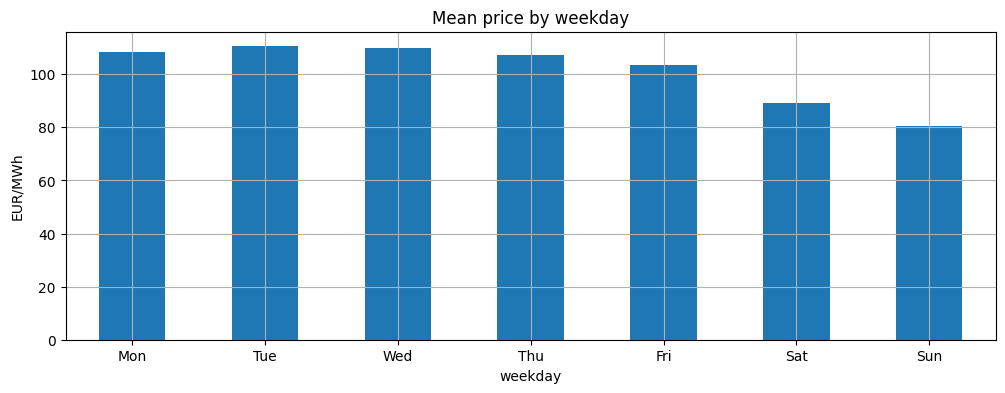

In [8]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax = df.groupby("weekday")["price_eur_mwh"].mean().plot(
    kind="bar", title="Mean price by weekday", color="tab:blue"
)
ax.set_xticklabels(weekday_names, rotation=0)
ax.set_ylabel("EUR/MWh")
plt.show()

## 3. Negative prices

Negative day-ahead prices mean producers pay to keep generating — typically
inflexible units plus subsidized RES during low demand / high solar hours.
They are real market outcomes and stay in the data; a model that cannot
predict them is useless for 2026.

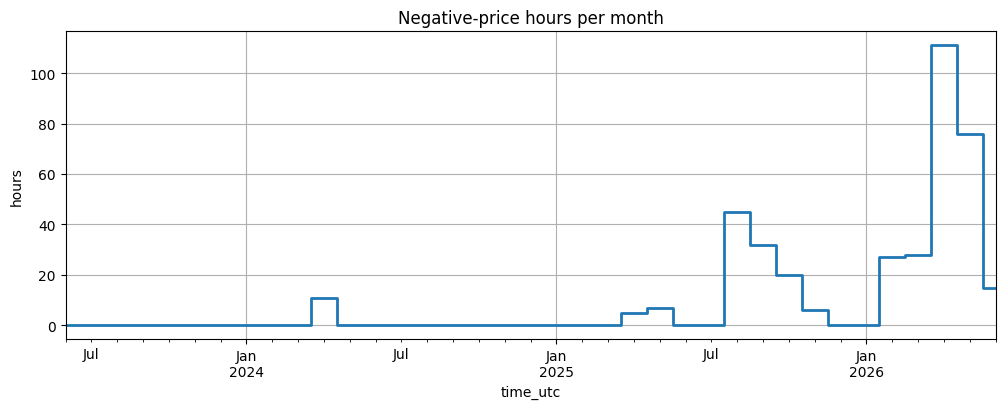

In [9]:
neg_per_month = (df["price_eur_mwh"] < 0).resample("MS").sum()
ax = neg_per_month.plot(drawstyle="steps-mid", lw=2, title="Negative-price hours per month")
ax.set_ylabel("hours")
plt.show()

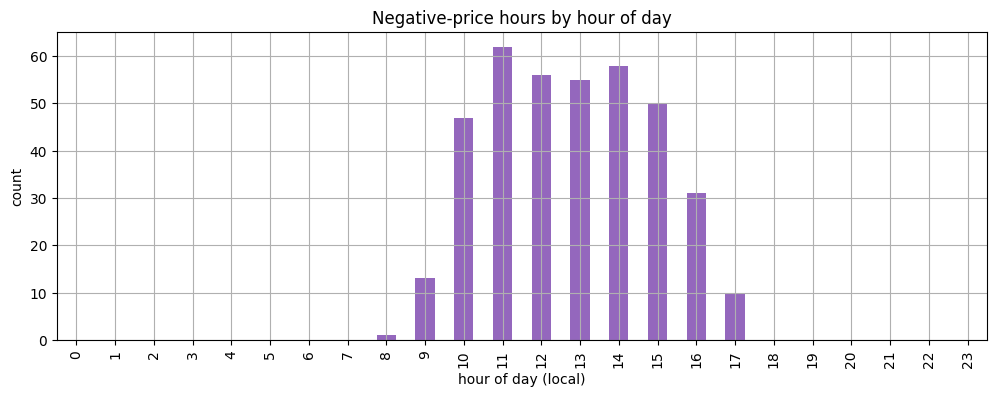

In [10]:
negative = df.loc[df["price_eur_mwh"] < 0]
neg_by_hour = negative.groupby("hour").size().reindex(range(24), fill_value=0)
ax = neg_by_hour.plot(kind="bar", color="tab:purple", title="Negative-price hours by hour of day")
ax.set_ylabel("count")
ax.set_xlabel("hour of day (local)")
plt.show()

In [11]:
episodes = quality.negative_price_episodes(df["price_eur_mwh"].dropna())
print(f"{len(episodes)} episodes, {episodes['hours'].sum()} hours total")
episodes.sort_values("hours", ascending=False).head(10)

88 episodes, 383 hours total


,start,end,hours,min_price,mean_price
76,2026-05-24 08:00:00+03:00,2026-05-24 17:00:00+03:00,10,-5.0000,-2.896250
84,2026-06-07 09:00:00+03:00,2026-06-07 17:00:00+03:00,9,-4.9950,-2.083333
55,2026-04-18 09:00:00+03:00,2026-04-18 17:00:00+03:00,9,-6.9100,-4.151111
61,2026-04-26 09:00:00+03:00,2026-04-26 17:00:00+03:00,9,-50.0000,-19.351667
47,2026-04-05 09:00:00+03:00,2026-04-05 17:00:00+03:00,9,-50.0000,-28.903889
9,2025-08-10 09:00:00+03:00,2025-08-10 16:00:00+03:00,8,-12.9200,-6.018750
8,2025-08-09 09:00:00+03:00,2025-08-09 16:00:00+03:00,8,-1.0000,-0.787500
48,2026-04-06 10:00:00+03:00,2026-04-06 17:00:00+03:00,8,-17.8275,-6.971562
75,2026-05-23 10:00:00+03:00,2026-05-23 17:00:00+03:00,8,-2.0850,-0.341250
60,2026-04-25 10:00:00+03:00,2026-04-25 17:00:00+03:00,8,-50.0000,-32.687188


## 4. Price vs residual load

The merit-order curve: dispatchable supply is offered at increasing marginal
cost, so price should rise steeply with residual load. Compare how much
better residual load explains price than raw load does.

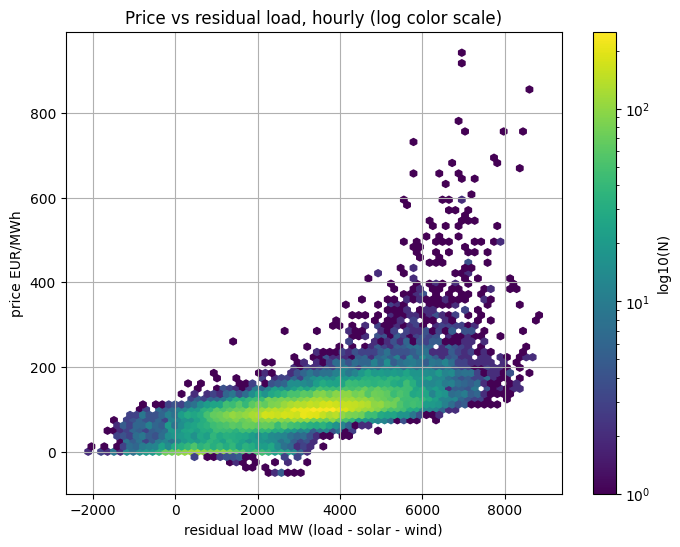

In [12]:
sub = df.dropna(subset=["price_eur_mwh", "residual_load_mw"])
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    sub["residual_load_mw"], sub["price_eur_mwh"], gridsize=70, bins="log", cmap="viridis"
)
ax.set_xlabel("residual load MW (load - solar - wind)")
ax.set_ylabel("price EUR/MWh")
ax.set_title("Price vs residual load, hourly (log color scale)")
fig.colorbar(hb, label="log10(N)")
plt.show()

In [13]:
corrs = sub.groupby("year").apply(
    lambda g: pd.Series(
        {
            "corr(price, load)": g["price_eur_mwh"].corr(g["load_actual_mw"]),
            "corr(price, residual_load)": g["price_eur_mwh"].corr(g["residual_load_mw"]),
        }
    )
)
corrs.round(3)

,"corr(price, load)","corr(price, residual_load)"
year,,
2023,0.224,0.605
2024,0.305,0.615
2025,0.137,0.718
2026,0.090,0.769


## Takeaways for modeling

- **Strong hour-of-day and weekday structure** → calendar features and the
  naive-24h / seasonal-naive-168h baselines (Phase 3) are meaningful bars.
- **The duck curve deepens every year** — the price distribution shifts over
  time, so a static train/test split would flatter the model. This motivates
  the walk-forward backtest with monthly retraining (Phase 5).
- **Negative prices are frequent and growing**; never clip or drop them.
  LightGBM regression handles negative targets natively.
- **Residual load beats raw load** as a price driver → the model should see
  the day-ahead load forecast (available before gate closure) and RES
  information. Caution for Phase 4: actual solar/wind generation is NOT
  known at issue time — only lagged values (or external forecasts) are
  legitimate features.
- **Heavy right tail** (spikes near 1000 EUR/MWh) → report MAE (robust) next
  to RMSE; conformal intervals (Phase 6) must cope with asymmetric noise.